# Electricity Demand Forecasting System

## Objective

The goal of this project is to forecast Ontario-wide hourly electricity demand using historical consumption data published by the Independent Electricity System Operator (IESO).

The project compares traditional machine learning and deep learning approaches for time-series forecasting by evaluating:

- A naïve persistence baseline
- An XGBoost regression model
- A PyTorch LSTM model

In this notebook, historical data from **Feburary 2026** is used for exploration. 
In the second notebook, data from **January and February 2026** is used for an attempt at training XGBoost.
Finally, in the third notebook, more data from **March 2024 through February 2026** is used for training and evaluation.

### Forecasting Task

Predict:

> Total Ontario electricity consumption one hour ahead

using historical consumption patterns and engineered temporal features.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile

plt.style.use("ggplot")
pd.set_option("display.max_columns", None)

# Data Loading

The IESO dataset is distributed as monthly ZIP archives containing hourly consumption records by:

- Forward Sortation Area (FSA)
- Customer Type
- Price Plan

To keep the repository lightweight, files are loaded directly from ZIP archives without extracting CSV files to disk.

Monthly datasets are combined into a single DataFrame for analysis and model development.

In [2]:
zip_path = "../data/raw_consumption_by_fsa/PUB_HourlyConsumptionByFSA_202602_v1.zip"

with zipfile.ZipFile(zip_path, "r") as z:
    print(z.namelist())

['PUB_HourlyConsumptionByFSA_202602_v1.csv', 'README.txt']


In [3]:
zip_path = (
    "../data/raw_consumption_by_fsa/"
    "PUB_HourlyConsumptionByFSA_202602_v1.zip"
)

with zipfile.ZipFile(zip_path) as z:
    csv_name = z.namelist()[0]

    with z.open(csv_name) as f:
        df = pd.read_csv(f, skiprows=3)

df.head()

,FSA,DATE,HOUR,CUSTOMER_TYPE,PRICE_PLAN,TOTAL_CONSUMPTION,PREMISE_COUNT
0,L4J,2026-02-01,1,Residential,Tiered,2875.398167,4113
1,M6A,2026-02-01,1,Residential,TOU,4813.104215,6791
2,N6,2026-02-01,1,SGS <50kW,Retailer,3563.127300,593
3,L7E,2026-02-01,1,Residential,TOU,13681.949441,9736
4,L7B,2026-02-01,1,Residential,TOU,12385.779041,4787


# Data Exploration

Before building forecasting models, the dataset structure is examined to understand:

- Available features
- Geographic coverage
- Customer categories
- Pricing plans
- Data quality



In [4]:
df.shape

(1431389, 7)

In [5]:
df.columns.tolist()

['FSA',
 'DATE',
 'HOUR',
 'CUSTOMER_TYPE',
 'PRICE_PLAN',
 'TOTAL_CONSUMPTION',
 'PREMISE_COUNT']

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1431389 entries, 0 to 1431388
Data columns (total 7 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   FSA                1431389 non-null  str    
 1   DATE               1431389 non-null  str    
 2   HOUR               1431389 non-null  int64  
 3   CUSTOMER_TYPE      1431389 non-null  str    
 4   PRICE_PLAN         1431389 non-null  str    
 5   TOTAL_CONSUMPTION  1431389 non-null  float64
 6   PREMISE_COUNT      1431389 non-null  int64  
dtypes: float64(1), int64(2), str(4)
memory usage: 76.4 MB


In [7]:
df.describe()

,HOUR,TOTAL_CONSUMPTION,PREMISE_COUNT
count,1.431389e+06,1.431389e+06,1.431389e+06
mean,1.249912e+01,3.410479e+03,2.486014e+03
std,6.922157e+00,1.179946e+04,7.975049e+03
min,1.000000e+00,1.290000e-01,1.500000e+01
25%,6.000000e+00,2.653110e+02,1.140000e+02
50%,1.200000e+01,9.092490e+02,4.980000e+02
75%,1.800000e+01,3.269634e+03,1.732000e+03
max,2.400000e+01,6.354855e+05,2.444240e+05


In [8]:
df.isnull().sum().sort_values(ascending=False)

FSA                  0
DATE                 0
HOUR                 0
CUSTOMER_TYPE        0
PRICE_PLAN           0
TOTAL_CONSUMPTION    0
PREMISE_COUNT        0
dtype: int64

In [9]:
df.sample(10)

,FSA,DATE,HOUR,CUSTOMER_TYPE,PRICE_PLAN,TOTAL_CONSUMPTION,PREMISE_COUNT
1014464,L4W,2026-02-20,20,Residential,TOU,5225.966896,4730
833889,N4N,2026-02-17,8,Residential,TOU,4721.416940,3992
1030713,L1V,2026-02-21,4,Residential,TOU,13114.305931,16194
1424711,N2R,2026-02-28,21,Residential,Retailer,16.850000,22
796410,N9J,2026-02-16,14,SGS <50kW,TOU,489.758000,212
1214390,M5G,2026-02-24,18,SGS <50kW,Tiered,608.864957,121
926240,K1G,2026-02-19,3,Residential,Tiered,1302.263310,2043
953499,M6J,2026-02-19,16,Residential,Retailer,47.338000,37
19916,M1R,2026-02-01,10,Residential,ULO,114.021341,74
946059,L6L,2026-02-19,12,SGS <50kW,Tiered,262.204582,38


In [10]:
df.nunique()

FSA                      564
DATE                      28
HOUR                      24
CUSTOMER_TYPE              2
PRICE_PLAN                 4
TOTAL_CONSUMPTION    1377089
PREMISE_COUNT           6020
dtype: int64

In [11]:
df["CUSTOMER_TYPE"].value_counts()

CUSTOMER_TYPE
Residential    909112
SGS <50kW      522277
Name: count, dtype: int64

In [12]:
df["PRICE_PLAN"].value_counts()

PRICE_PLAN
TOU         585885
Tiered      452251
Retailer    244741
ULO         148512
Name: count, dtype: int64

In [13]:
df["FSA"].nunique()

564

In [14]:
df["FSA"].value_counts().head(20)

FSA
M6A    4704
M6H    4704
P0     4704
M6B    4704
M6C    4704
N0P    4704
M6P    4704
M6E    4704
M6S    4704
M6J    4704
N0K    4704
N0E    4704
M6L    4704
M6K    4704
N0J    4704
M6M    4704
N0B    4704
N0H    4704
N0R    4704
N0G    4704
Name: count, dtype: int64

### Key findings:

- 564 unique FSAs
- 2 customer types
- 4 pricing plans
- Hourly consumption measurements


### Create the timestamp column

In [15]:
df["timestamp"] = (
    pd.to_datetime(df["DATE"])
    + pd.to_timedelta(df["HOUR"] - 1, unit="h")
)

df[["DATE", "HOUR", "timestamp"]].head()

,DATE,HOUR,timestamp
0,2026-02-01,1,2026-02-01
1,2026-02-01,1,2026-02-01
2,2026-02-01,1,2026-02-01
3,2026-02-01,1,2026-02-01
4,2026-02-01,1,2026-02-01


In [16]:
df.head()

,FSA,DATE,HOUR,CUSTOMER_TYPE,PRICE_PLAN,TOTAL_CONSUMPTION,PREMISE_COUNT,timestamp
0,L4J,2026-02-01,1,Residential,Tiered,2875.398167,4113,2026-02-01
1,M6A,2026-02-01,1,Residential,TOU,4813.104215,6791,2026-02-01
2,N6,2026-02-01,1,SGS <50kW,Retailer,3563.127300,593,2026-02-01
3,L7E,2026-02-01,1,Residential,TOU,13681.949441,9736,2026-02-01
4,L7B,2026-02-01,1,Residential,TOU,12385.779041,4787,2026-02-01


In [17]:
df["timestamp"].dtype

dtype('<M8[us]')

In [18]:
df[["HOUR", "timestamp"]].sample(20).sort_values("HOUR")

,HOUR,timestamp
206315,1,2026-02-05 00:00:00
1176771,1,2026-02-24 00:00:00
617920,2,2026-02-13 01:00:00
363356,3,2026-02-08 02:00:00
267504,6,2026-02-06 05:00:00
833101,7,2026-02-17 06:00:00
272233,8,2026-02-06 07:00:00
220677,8,2026-02-05 07:00:00
275244,9,2026-02-06 08:00:00
432174,11,2026-02-09 10:00:00


### What should be predicted?

In [19]:
df["FSA"].nunique()

564

In [20]:
df["CUSTOMER_TYPE"].value_counts()

CUSTOMER_TYPE
Residential    909112
SGS <50kW      522277
Name: count, dtype: int64

In [21]:
df["PRICE_PLAN"].value_counts()

PRICE_PLAN
TOU         585885
Tiered      452251
Retailer    244741
ULO         148512
Name: count, dtype: int64

# Aggregation

The original dataset contains separate records for different:

- FSAs
- Customer types
- Price plans

For the first forecasting model, hourly demand is aggregated across all records to create a single Ontario-wide electricity demand time series.

This simplifies the forecasting problem and allows the focus to be placed on model development and evaluation.

In [22]:
df["timestamp"] = (
    pd.to_datetime(df["DATE"])
    + pd.to_timedelta(df["HOUR"] - 1, unit="h")
)

ontario_hourly = (
    df.groupby("timestamp", as_index=False)
      .agg({
          "TOTAL_CONSUMPTION": "sum",
          "PREMISE_COUNT": "sum"
      })
)

ontario_hourly.head()

,timestamp,TOTAL_CONSUMPTION,PREMISE_COUNT
0,2026-02-01 00:00:00,7.472171e+06,5294230
1,2026-02-01 01:00:00,7.157012e+06,5294706
2,2026-02-01 02:00:00,6.940772e+06,5294715
3,2026-02-01 03:00:00,6.824741e+06,5294709
4,2026-02-01 04:00:00,6.813344e+06,5294718


In [23]:
ontario_hourly.shape

(672, 3)

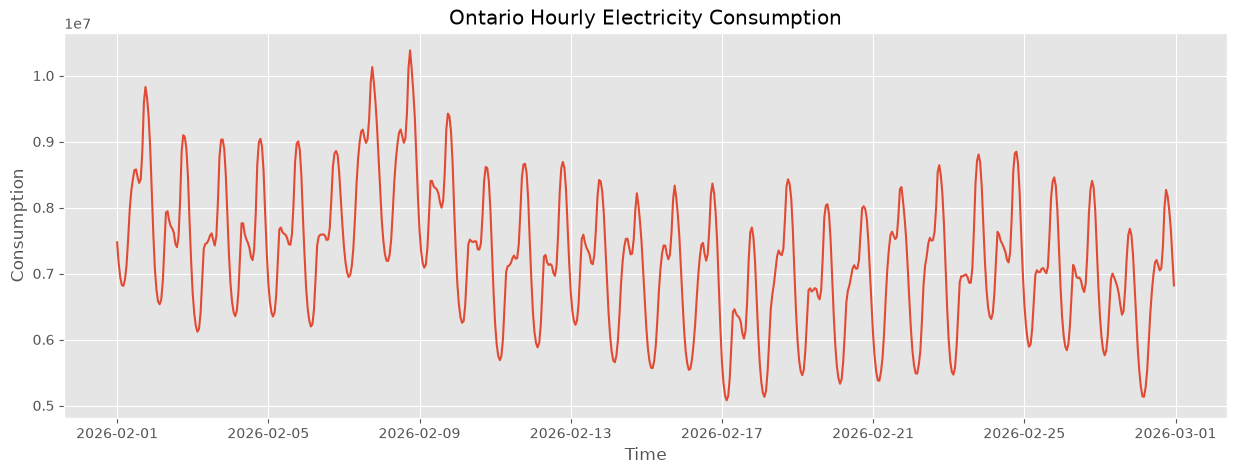

In [24]:
plt.figure(figsize=(15,5))

plt.plot(
    ontario_hourly["timestamp"],
    ontario_hourly["TOTAL_CONSUMPTION"]
)

plt.title("Ontario Hourly Electricity Consumption")
plt.xlabel("Time")
plt.ylabel("Consumption")
plt.show()

In [25]:
ontario_hourly.shape

(672, 3)

In [26]:
ontario_hourly.head()

,timestamp,TOTAL_CONSUMPTION,PREMISE_COUNT
0,2026-02-01 00:00:00,7.472171e+06,5294230
1,2026-02-01 01:00:00,7.157012e+06,5294706
2,2026-02-01 02:00:00,6.940772e+06,5294715
3,2026-02-01 03:00:00,6.824741e+06,5294709
4,2026-02-01 04:00:00,6.813344e+06,5294718


In [27]:
ontario_hourly.tail()

,timestamp,TOTAL_CONSUMPTION,PREMISE_COUNT
667,2026-02-28 19:00:00,8.171924e+06,5295595
668,2026-02-28 20:00:00,7.963853e+06,5295593
669,2026-02-28 21:00:00,7.678498e+06,5295588
670,2026-02-28 22:00:00,7.263470e+06,5295588
671,2026-02-28 23:00:00,6.819851e+06,5297273


### Feature selection
Electricity demand is highly seasonal:
- Hour 8 AM today resembles hour 8 AM yesterday.
- Monday morning resembles previous Monday morning